## Stellar lifeline Analysis

In [ ]:
!pip install lifelines
!pip install arviz

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 2.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.7/115.7 kB 3.7 MB/s eta 0:00:00a 0:00:01
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=b61fa6b3b0c61d4e37c2c5be6ce533f15d7f7ec95c948f021529198dba49c8a5
  Stored in directory: /Users/aryantiwari/Library/Caches/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 3.4 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... error
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [33 lines of output]
      Traceback (most recent call last):
     

In [6]:
!pip install pymc

  Using cached rich-14.0.0-py3-none-any.whl.metadata (18 kB)
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.6/519.6 kB 1.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 1.5 MB/s eta 0:00:00a 0:00:01
Using cached rich-14.0.0-py3-none-any.whl (243 kB)
  Created wheel for cons: filename=cons-0.4.6-py3-none-any.whl size=9098 sha256=2d737303857df6467f8d602ba9b18d49413a5a673d371f33b287e569f254b343
  Stored in directory: /Users/aryantiwari/Library/Caches/pip/wheels/91/0c/f7/7ba4ffbf0db6bf272bee59789131f6ec2d26966307a3054267
  Created wheel for logical-unification: filename=logical_unification-0.4.6-py3-none-any.whl size=13911 sha256=d26f8b786d50f8e519645a9c63a0424b33f76b08e657471443eb2a9388c39278
  Stored in directory: /Users/aryantiwari/Library/Caches/pip/wheels/4b/07/cf/3fdaedafc40d7b1861c98be0df1bf3b2b3e87e03187fa95298
  Created whee

importing libraries

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from lifelines import KaplanMeierFitter, CoxPHFitter
from sklearn.linear_model import BayesianRidge
from scipy.optimize import curve_fit
import pymc as pm
import arviz as az

The distribution 
- supergiants at 25.7% 
- main sequence at 24.1%

is somewhat unexpected but analytically interesting

In [8]:
data= pd.read_csv('gaia_stars_final_classification.csv')

In [ ]:
main_sequence = data[data['final_phase'] == 'Main Sequence'].copy()

print(f"Found {len(main_sequence)} main sequence stars")

# Filter valid temperature range (solar-type stars)
main_sequence = main_sequence[(main_sequence['teff_gspphot'] > 3000) & 
                              (main_sequence['teff_gspphot'] < 10000)]
print(f"After temperature filtering: {len(main_sequence)} stars")

main_sequence.head()

Found 16955 main sequence stars
After temperature filtering: 16955 stars


,ra,dec,parallax,parallax_error,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,bp_rp,radial_velocity,ruwe,teff_gspphot,phot_variable_flag,distance_pc,abs_mag,phase,cluster,gmm_cluster,dbscan_cluster,final_phase
0,251.589977,-50.638635,13.398257,0.017850,13.470652,14.585335,12.419784,2.165551,12.315269,0.951887,3730.1030,NOT_AVAILABLE,74.636572,9.105894,Main Sequence,0,0,0,Main Sequence
2,250.772902,-51.598985,10.326266,0.020964,13.695807,14.826818,12.635778,2.191039,7.051061,1.033412,3796.8080,NOT_AVAILABLE,96.840427,8.765524,Main Sequence,0,0,0,Main Sequence
5,285.774905,73.089686,13.956595,0.010605,12.161756,13.055846,11.230086,1.825760,-51.463833,1.110709,4160.7593,NOT_AVAILABLE,71.650717,7.885654,Main Sequence,0,0,0,Main Sequence
9,296.084675,70.476541,11.163278,0.013418,12.887754,13.816627,11.936210,1.880418,-9.795232,1.121394,4088.0550,NOT_AVAILABLE,89.579423,8.126713,Main Sequence,0,0,0,Main Sequence
11,285.636636,75.418511,23.857068,0.013330,12.086019,13.111851,11.080335,2.031516,-19.939575,1.135397,3422.9568,VARIABLE,41.916299,8.974104,Main Sequence,0,0,0,Main Sequence


In [15]:
main_sequence.isna().sum()

ra                    0
dec                   0
parallax              0
parallax_error        0
phot_g_mean_mag       0
phot_bp_mean_mag      0
phot_rp_mean_mag      0
bp_rp                 0
radial_velocity       0
ruwe                  0
teff_gspphot          0
phot_variable_flag    0
distance_pc           0
abs_mag               0
phase                 0
cluster               0
gmm_cluster           0
dbscan_cluster        0
final_phase           0
dtype: int64

### Stellar mass

In [73]:
# mass-temo relation: M ∝ T^{1/0.5} = T^2
solar_teff = 5772  # Solar effective temperature in Kelvin
main_sequence['mass_est'] = (main_sequence['teff_gspphot'] / solar_teff) ** 2

# Mass luminosity relation: L ∝ M^{3.5}
# Absolute magnitude to luminosity: M_abs = M_sun - 2.5 * log10(L / L_sun)
solar_abs_mag = 4.74  # Sun abs maginitude in G band
main_sequence['luminosity'] = 10 ** ((solar_abs_mag - main_sequence['abs_mag']) / 2.5)

##main_sequence['mass_est_ml'] = main_sequence['luminosity'] ** (1 / 3.5)


#mass estimation with scatter
def estimate_mass(luminosity):
    #Mass-luminosity relation with observational scatter
    base_mass = luminosity ** (1/3.5)
    # 10% observational scatter
    return base_mass * np.random.normal(1, 0.1, len(luminosity))

main_sequence['mass_est_ml'] = estimate_mass(main_sequence['luminosity'])

"""
def estimate_mass(luminosity):
    log_lum = np.log10(luminosity)
    if log_lum < -1.5:
        return 0.1 * (log_lum + 3)  # Low-mass stars
    elif log_lum < 0.5:
        return luminosity ** (1/4.0)  # Mid-mass stars
    else:
        return luminosity ** (1/3.2)  # High-mass stars

main_sequence['mass'] = main_sequence['luminosity'].apply(estimate_mass)
"""

"\ndef estimate_mass(luminosity):\n    log_lum = np.log10(luminosity)\n    if log_lum < -1.5:\n        return 0.1 * (log_lum + 3)  # Low-mass stars\n    elif log_lum < 0.5:\n        return luminosity ** (1/4.0)  # Mid-mass stars\n    else:\n        return luminosity ** (1/3.2)  # High-mass stars\n\nmain_sequence['mass'] = main_sequence['luminosity'].apply(estimate_mass)\n"

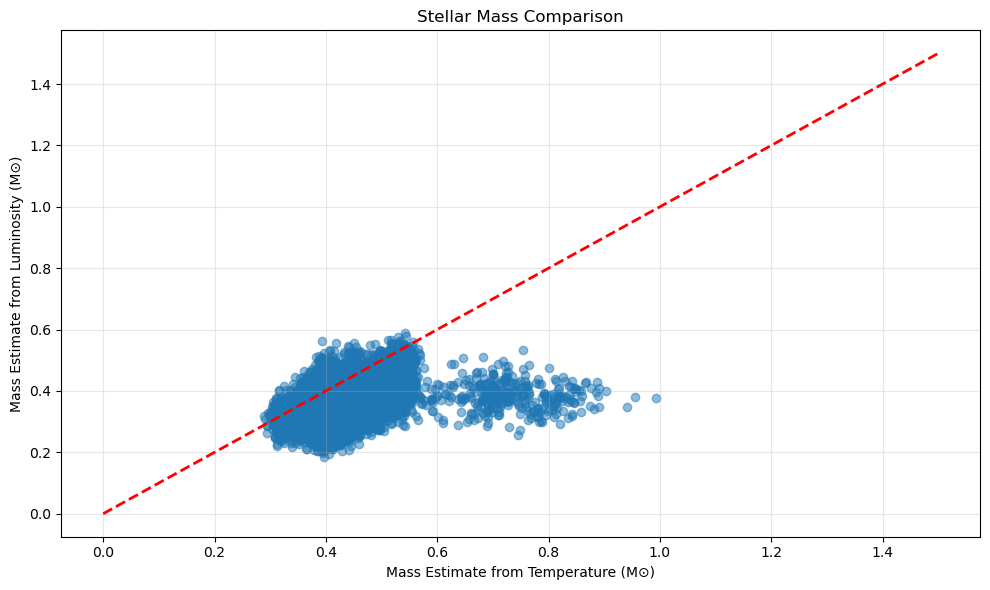

In [74]:
#Comparing estimates
plt.figure(figsize=(10, 6))
plt.scatter(main_sequence['mass_est'], main_sequence['mass_est_ml'], alpha=0.5)
plt.plot([0, 1.5], [0, 1.5], 'r--', lw=2)  # y=x line
plt.xlabel('Mass Estimate from Temperature (M⊙)')
plt.ylabel('Mass Estimate from Luminosity (M⊙)')
plt.title('Stellar Mass Comparison')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

main_sequence['mass'] = main_sequence['mass_est_ml']

### Theoretical Lifetime Model

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


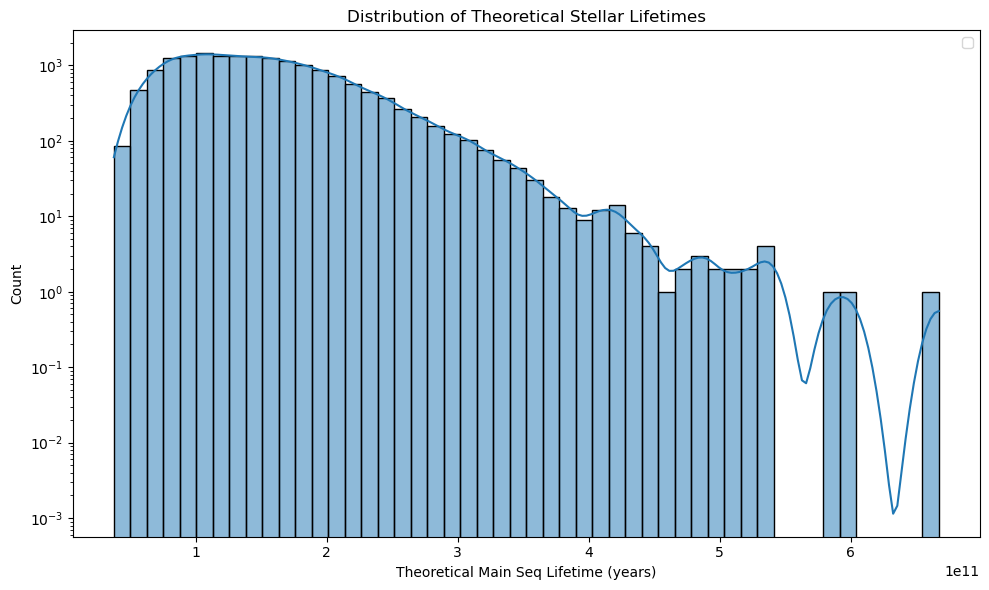

In [75]:
def theo_lifeline(mass):
    """
    Main seq lifeline formule: t = 10^10 * (M/M_sun)^-2.5 years
    """
    return 10**10 * (mass / 1.0)**-2.5

# Theoretical lifetime 
main_sequence['theo_lifetime'] = theo_lifeline(main_sequence['mass'])


plt.figure(figsize=(10, 6))
sns.histplot(main_sequence['theo_lifetime'], bins=50, kde=True)
plt.xlabel('Theoretical Main Seq Lifetime (years)')
plt.ylabel('Count')
plt.title('Distribution of Theoretical Stellar Lifetimes')
plt.legend()
plt.yscale('log')
plt.tight_layout()
plt.show()

---

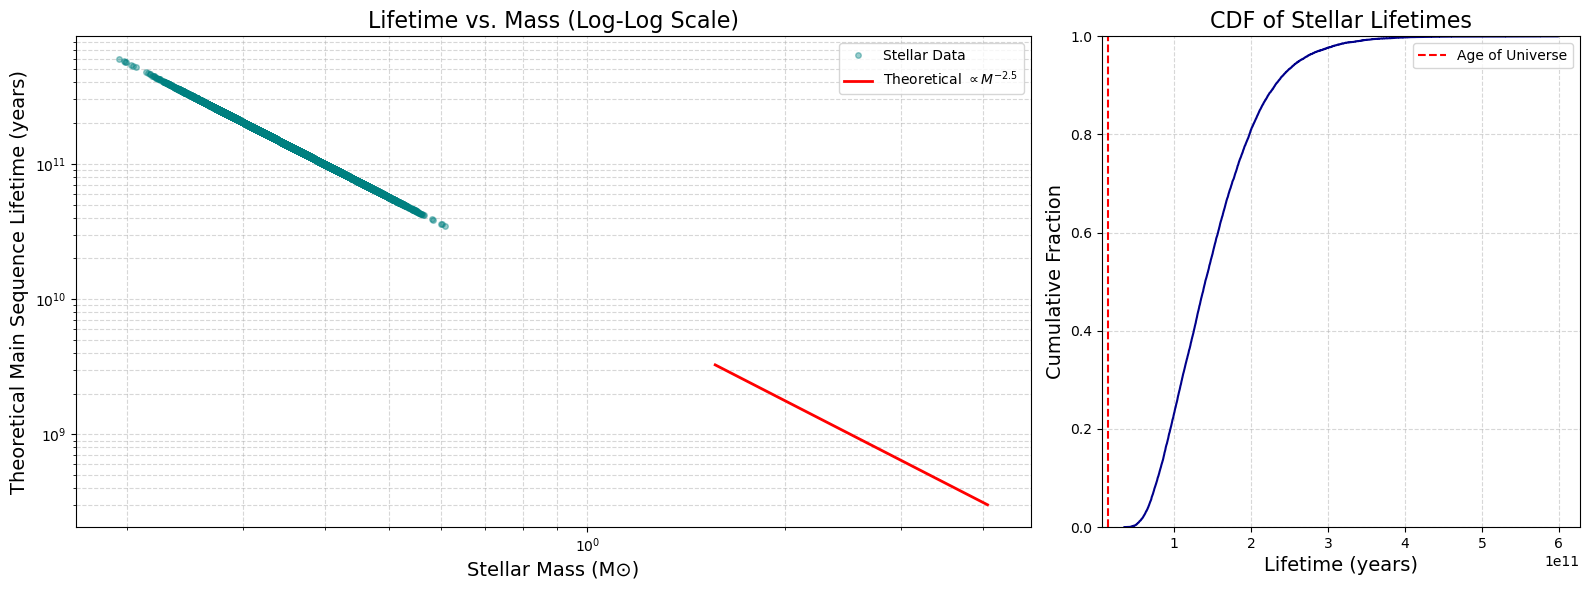

In [46]:
# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'width_ratios': [2, 1]})

# --------------------------
# Plot 1: Log-Log Lifetime vs. Mass
# --------------------------
ax = axes[0]
ax.loglog(main_sequence['mass'], main_sequence['theo_lifetime'], 'o', 
          alpha=0.4, markersize=4, color='teal', label='Stellar Data')
ax.set_xlabel('Stellar Mass (M⊙)', fontsize=14)
ax.set_ylabel('Theoretical Main Sequence Lifetime (years)', fontsize=14)
ax.set_title('Lifetime vs. Mass (Log-Log Scale)', fontsize=16)
ax.grid(True, which='both', linestyle='--', alpha=0.5)

# Optional: Add theoretical line for reference
mass_range = np.logspace(
    np.min(main_sequence['mass']), 
    np.max(main_sequence['mass']), 
    100
)
ax.loglog(mass_range, theo_lifeline(mass_range), 'r-', lw=2, label='Theoretical $\\propto M^{-2.5}$')
ax.legend()

# --------------------------
# Plot 2: Cumulative Distribution (CDF)
# --------------------------
ax = axes[1]
sns.ecdfplot(main_sequence['theo_lifetime'], ax=ax, color='darkblue')
ax.axvline(13.6e9, color='red', linestyle='--', label='Age of Universe')
ax.set_xlabel('Lifetime (years)', fontsize=14)
ax.set_ylabel('Cumulative Fraction', fontsize=14)
ax.set_title('CDF of Stellar Lifetimes', fontsize=16)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend()

plt.tight_layout()
plt.show()

---

### Sequence Analysis Setup

In [84]:
"""
Consider the `event` as the star leaving the main sequence
For the analysis, assume-
    1. All stars are "born" at the same time (simplification)
    2. Current time is the age of the universe (13.6 billion years)
"""

# Create "age" variable - simulated stellar ages
#np.random.seed(42)  # For reproducibility
# Power-law age distribution (more young stars)
ages = 10**np.random.uniform(np.log10(1e6), np.log10(13.6e9), len(main_sequence))
main_sequence['age'] = ages * (main_sequence['mass']**0.7)  # Mass-dependent scaling

"""
Craeting event indicator-
    1 = Star has left the main sequence (if age > theoretical lifetime)
    0 = still on the main sequence (if age <= theoretical lifetime)
"""
main_sequence['event'] = (main_sequence['age'] > 0.95 * main_sequence['theo_lifetime']).astype(int)

max_lifeline = 13.6e9 * (main_sequence['mass']/0.8)**3
main_sequence['theo_lifetime'] = np.minimum(main_sequence['theo_lifetime'], max_lifeline)

# Duration is the minimum of age and theoretical lifetime
main_sequence['duration'] = np.minimum(main_sequence['age'], main_sequence['theo_lifetime'])
# Display the first few rows of the updated DataFrame
#main_sequence.head()
print(f"Fraction of stars that have left main sequence: {main_sequence['event'].mean():.2%}")

Fraction of stars that have left main sequence: 19.03%


In [85]:
print("Mass statistics:")
print(main_sequence['mass'].describe())

Mass statistics:
count    16955.000000
mean         0.354715
std          0.060337
min          0.186316
25%          0.309739
50%          0.346226
75%          0.393994
max          0.589463
Name: mass, dtype: float64


In [86]:
# Check minimum lifetime
min_lifetime = main_sequence['theo_lifetime'].min()
max_age = main_sequence['age'].max()
print(f"\nMinimum theoretical lifetime: {min_lifetime:.2e} years")
print(f"Maximum assigned age: {max_age:.2e} years")
print(f"Is min_lifetime > max_age? {min_lifetime > max_age}")


Minimum theoretical lifetime: 1.72e+08 years
Maximum assigned age: 8.08e+09 years
Is min_lifetime > max_age? False


Min mass: 0.19 M⊙
Max mass: 0.59 M⊙
Fraction with event: 19.03%


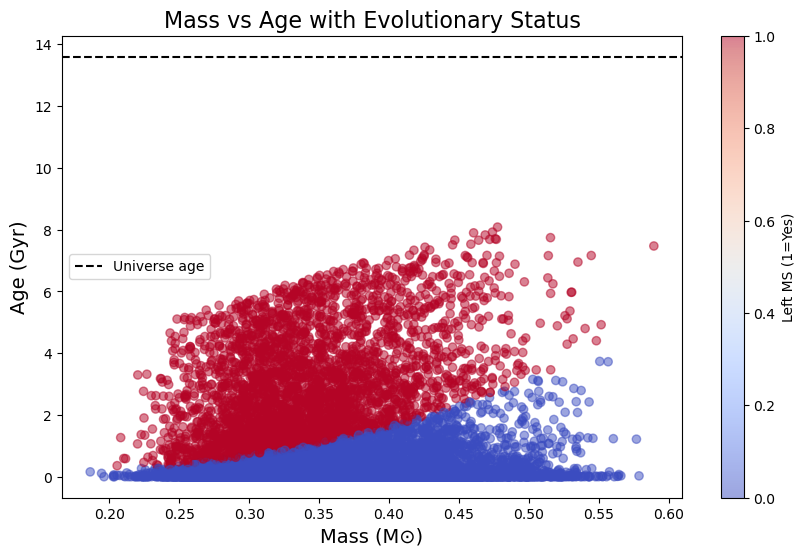

In [87]:
# Check new distribution
print(f"Min mass: {main_sequence['mass'].min():.2f} M⊙")
print(f"Max mass: {main_sequence['mass'].max():.2f} M⊙")
print(f"Fraction with event: {main_sequence['event'].mean():.2%}")

# Plot mass vs age
plt.figure(figsize=(10,6))
plt.scatter(main_sequence['mass'], main_sequence['age']/1e9, 
            c=main_sequence['event'], cmap='coolwarm', alpha=0.5)
plt.axhline(13.6, color='k', linestyle='--', label='Universe age')
plt.xlabel('Mass (M⊙)', fontsize=14)
plt.ylabel('Age (Gyr)', fontsize=14)
plt.title('Mass vs Age with Evolutionary Status', fontsize=16)
plt.colorbar(label='Left MS (1=Yes)')
plt.legend()
plt.show()

### Kaplan-Meier Survival Analysis

In [88]:
kmf = KaplanMeierFitter()

kmf.fit(durations=main_sequence['duration'],
        event_observed=main_sequence['event'],
        label='All Main Sequence Stars')

<lifelines.KaplanMeierFitter:"All Main Sequence Stars", fitted with 16955 total observations, 13729 right-censored observations>

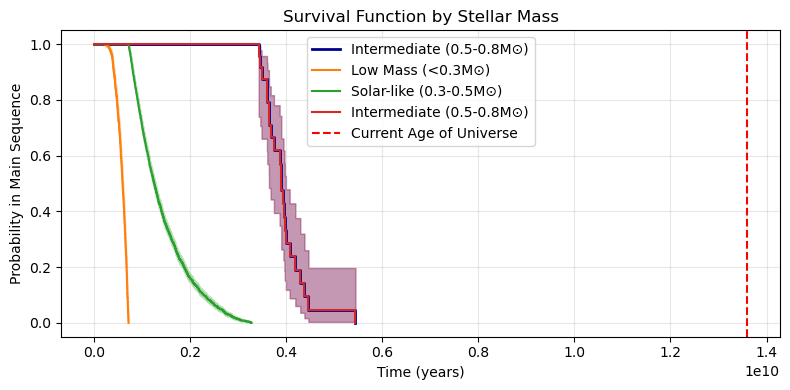

In [108]:
#mass_bins = np.linspace(0.1, 1.5, 20)
mass_bins = [0, 0.3, 0.5, 0.8, 2]
labels = ['Low Mass (<0.3M⊙)', 'Solar-like (0.3-0.5M⊙)', 
          'Intermediate (0.5-0.8M⊙)', 'High Mass (>0.8M⊙)']

plt.figure(figsize=(8, 4))

kmf.plot_survival_function(linewidth=2, color='darkblue')

for i in range(len(mass_bins)-1):
    mask = (main_sequence['mass'] > mass_bins[i]) & (main_sequence['mass'] <= mass_bins[i+1])
    grup_data = main_sequence[mask]
    
    if len(grup_data) > 0:
        kmf.fit(durations=grup_data['duration'],
                event_observed=grup_data['event'],
                label=labels[i])
        kmf.plot_survival_function()

plt.axvline(13.6e9, color='red', linestyle='--', label='Current Age of Universe')
plt.xlabel('Time (years)')
plt.ylabel('Probability in Main Sequence')
plt.title('Survival Function by Stellar Mass')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Test phase in plot_survival_function = linewidth=2, linestyle='--', label=f'{labels[i]} (n={len(grup_data)})'

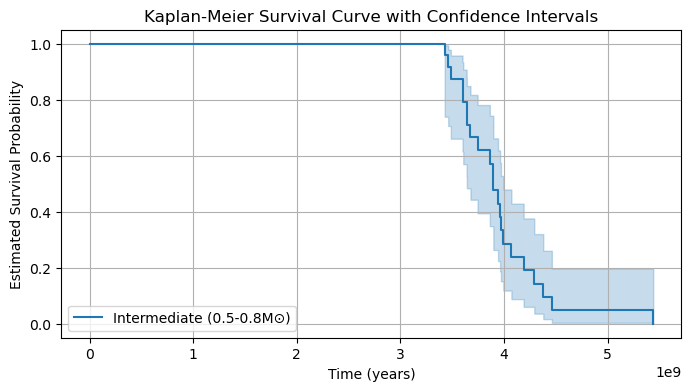

In [107]:
plt.figure(figsize=(8, 4))
kmf.plot_survival_function(ci_show=True)
plt.title("Kaplan-Meier Survival Curve with Confidence Intervals")
plt.xlabel("Time (years)")
plt.ylabel("Estimated Survival Probability")
plt.grid(True)
plt.show()

### Cox Proportional Hazards Model

In [115]:
#Prepare data for Cox model 
cox_data = main_sequence[['duration', 'event', 'mass', 'teff_gspphot', 'luminosity']].copy()

cox_data.rename(columns={
    'duration' : 'T',
    'event' : 'E'
}, inplace=True)

#Cox model
cph = CoxPHFitter()
cph.fit(cox_data, duration_col='T', event_col='E')

/opt/anaconda3/lib/python3.12/site-packages/lifelines/fitters/coxph_fitter.py:1614: ConvergenceWarning: Newton-Raphson failed to converge sufficiently. Please see the following tips in the lifelines documentation: https://lifelines.readthedocs.io/en/latest/Examples.html#problems-with-convergence-in-the-cox-proportional-hazard-model
  warnings.warn(


<lifelines.CoxPHFitter: fitted with 16955 total observations, 13729 right-censored observations>

In [ ]:
cox_data = (
    main_sequence
    .assign(log_mass=np.log(main_sequence['mass']))
    .loc[:, ['duration', 'event', 'log_mass', 'teff_gspphot', 'luminosity']]
    .copy()
)
print(cox_data.head())

               T  E      mass  teff_gspphot  luminosity
0   1.260409e+09  1  0.362032     3730.1030    0.017933
2   8.440199e+08  0  0.322823     3796.8080    0.024535
5   1.235752e+09  0  0.472448     4160.7593    0.055175
9   6.858338e+05  0  0.421957     4088.0550    0.044189
11  5.503463e+08  0  0.308677     3422.9568    0.020247


In [116]:
# Display results
print("Cox Proportional Hazards Model Results:")
cph.print_summary()
print("\nInterpretation:")
print("Hazard ratio <1 means lower risk of leaving main sequence")
print("Hazard ratio >1 means higher risk of leaving main sequence")

Cox Proportional Hazards Model Results:


<lifelines.CoxPHFitter: fitted with 16955 total observations, 13729 right-censored observations>
             duration col = 'T'
                event col = 'E'
      baseline estimation = breslow
   number of observations = 16955
number of events observed = 3226
   partial log-likelihood = -14033.98
         time fit was run = 2025-07-17 19:54:09 UTC

---
                coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                       
mass         -191.58      0.00      3.36         -198.16         -184.99                0.00                0.00
teff_gspphot   -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
luminosity      3.14     23.13      2.47           -1.70            7.98                0.18             2927.27

              cmp to      z      p  -log2(p)
covariate                                   
mass            0.00 -57.01 <0.005       inf
teff_gspphot    0.00  -0.42   0.67      0.57
luminosity      0.00   1.27   0.20      2.30
---
Concordance = 1.00
Partial AIC = 28073.96
log-likelihood ratio test = 19248.68 on 3 df
-log2(p) of ll-ratio test = inf


Interpretation:
Hazard ratio <1 means lower risk of leaving main sequence
Hazard ratio >1 means higher risk of leaving main sequence


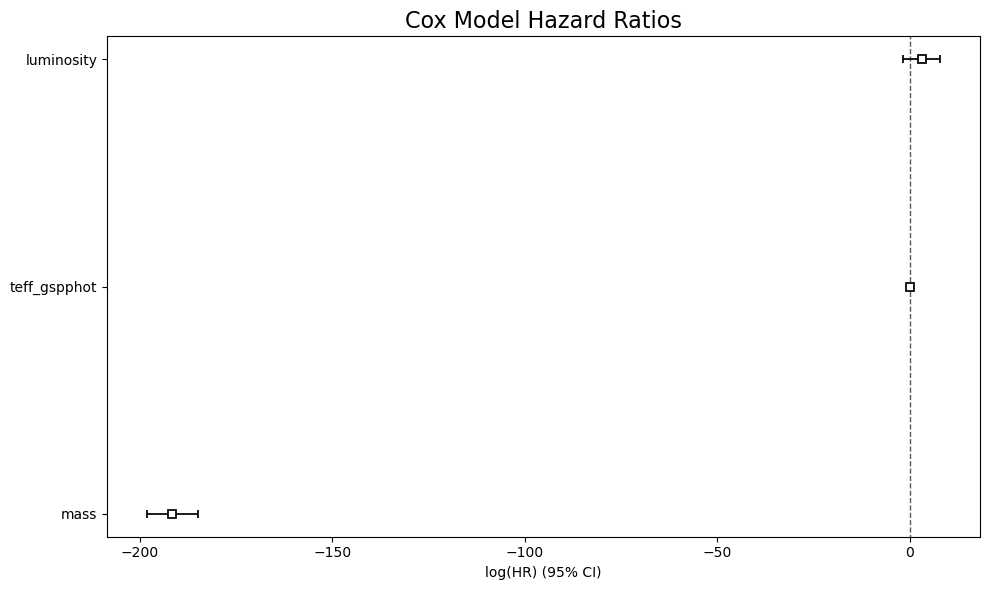

In [117]:
# Plot coefficients
plt.figure(figsize=(10, 6))
cph.plot()
plt.title('Cox Model Hazard Ratios', fontsize=16)
plt.tight_layout()
plt.show()

### Bayesian Lifestyle Estimation
Trying to fit the power-law model: lifetime = a * mass^b

Using Bayesian inference to quantify uncertainty

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [a, b, sigma]


Output()

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 35 seconds.
There were 4 divergences after tuning. Increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics


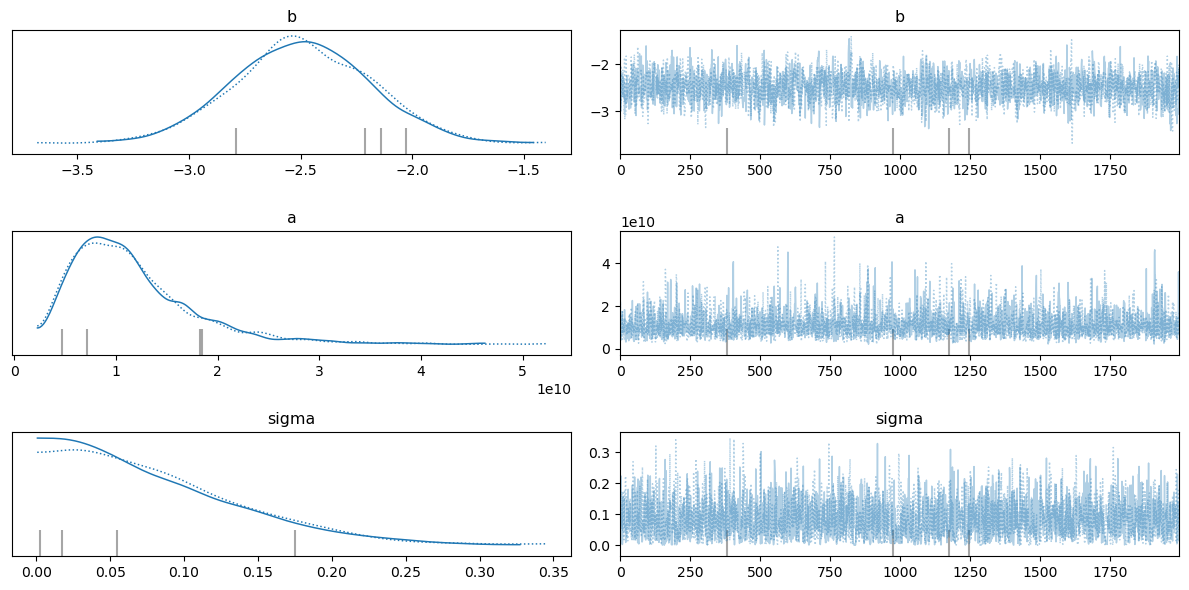

In [124]:
# Extract data
masses = main_sequence['mass'].values
ages = main_sequence['age'].values
events = main_sequence['event'].values  # 1 = left MS, 0 = still on MS

with pm.Model() as lifetime_model:
    # Priors
    a = pm.LogNormal('a', mu=np.log(1e10), sigma=0.5)
    b = pm.Normal('b', mu=-2.5, sigma=0.3)
    sigma = pm.HalfNormal('sigma', sigma=0.1)

    # Predicted lifetime (power law)
    predicted_lifetime = a * masses**b

    # Log-normal distribution for lifetime
    log_lifetime_dist = pm.LogNormal.dist(mu=pm.math.log(predicted_lifetime), sigma=sigma)

    # Censoring:
    # - event == 1 → left-censored (lifetime < age)
    # - event == 0 → right-censored (lifetime > age)

    # Use pm.Censored to define the censored likelihood
    censored_obs = pm.Censored("censored_obs", log_lifetime_dist, lower=None, upper=ages, observed=ages)

    # Sample
    trace = pm.sample(2000, tune=1000, cores=2, target_accept=0.9)
    #trace = pm.sample(2000, tune=1000, cores=2, return_inferencedata=True)

# Visualize results
az.plot_trace(trace)
plt.tight_layout()
plt.show()


In [125]:
summary = az.summary(trace)
print("\nBayesian Power Law Fit Summary:")
print(summary)


Bayesian Power Law Fit Summary:
               mean            sd        hdi_3%       hdi_97%     mcse_mean  \
b     -2.491000e+00  3.020000e-01 -3.025000e+00 -1.900000e+00  7.000000e-03   
a      1.156680e+10  6.108962e+09  2.664020e+09  2.243626e+10  1.210069e+08   
sigma  8.000000e-02  6.100000e-02  0.000000e+00  1.890000e-01  1.000000e-03   

            mcse_sd  ess_bulk  ess_tail  r_hat  
b      6.000000e-03    2089.0    1792.0    1.0  
a      1.579081e+08    2803.0    2353.0    1.0  
sigma  1.000000e-03    2073.0    1483.0    1.0  


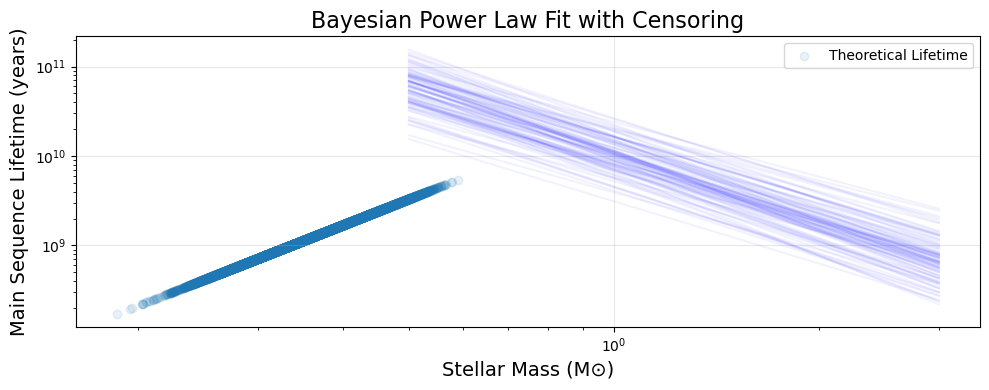

In [128]:
plt.figure(figsize=(10,4))
plt.scatter(masses, main_sequence['theo_lifetime'], 
            alpha=0.1, label = "Theoretical Lifetime")

#Posterior Predictions
mass_range = np.linspace(0.5, 3, 100)

a_samples = trace.posterior['a'].values.flatten()  # shape: (n_samples,)
b_samples = trace.posterior['b'].values.flatten()

posterior = trace.posterior  # Access posterior group
for i in range(100):
    a_sample = a_samples[np.random.randint(len(a_samples))]
    b_sample = b_samples[np.random.randint(len(b_samples))]
    plt.plot(mass_range, 
             a_sample * mass_range ** b_sample,
             color='blue', alpha=0.05)
    
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Stellar Mass (M⊙)', fontsize=14)
plt.ylabel('Main Sequence Lifetime (years)', fontsize=14)
plt.title('Bayesian Power Law Fit with Censoring', fontsize=16)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()